## **1. Download Kaggle breast ultrasound images dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Path to dataset files: /kaggle/input/breast-ultrasound-images-dataset


### 1.1 Import libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model

In [ ]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please enable it in Runtime > Change runtime type.')
else:
  print(f'Found GPU at: {device_name}')

# Check physical devices detected by TF
print("Physical Devices:", tf.config.list_physical_devices('GPU'))

Found GPU at: /device:GPU:0
Physical Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2 Defining the path to the 2 folders `benign` and `malignant`

In [ ]:
# List the contents of the path returned by kagglehub to see the exact structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:2]: # Show just 2 files per folder for brevity
        print(f'{subindent}{f}')

breast-ultrasound-images-dataset/
    Dataset_BUSI_with_GT/
        benign/
            benign (2).png
            benign (285).png
        normal/
            normal (28).png
            normal (51).png
        malignant/
            malignant (71).png
            malignant (196).png


In [ ]:
# Using the 'path' variable from kagglehub to define subdirectories
benign_path = os.path.join(path, 'Dataset_BUSI_with_GT', 'benign')
malignant_path = os.path.join(path, 'Dataset_BUSI_with_GT', 'malignant')
normal_path = os.path.join(path, 'Dataset_BUSI_with_GT', 'normal')

folder_paths = [benign_path, malignant_path]
print(f"Paths defined:\nBenign: {benign_path}\nMalignant: {malignant_path}")

Paths defined:
Benign: /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign
Malignant: /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant


## **2. Implementing U-net**

The original image dimension is 483 x 560 x 3

We want the size to be 128 x 128 x 1

In [ ]:
size = 128 # Input size: 128x128

images = []; masks = []

In [ ]:
for folder in folder_paths:
    # Get all image paths in the current folder
    file_list = glob(os.path.join(folder, "*.png"))

    for file_path in file_list:
        # Skip files that are masks to separate images from masks
        if "_mask" in file_path:
            continue

        # 1. Load and process the original image
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (size, size))
            images.append(img)

            # 2. Load and process the corresponding mask
            mask_path = file_path.replace(".png", "_mask.png")
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, (size, size))
                masks.append(mask)
            else:
                # Add a blank mask if missing
                masks.append(np.zeros((size, size)))

# Convert lists to numpy arrays and normalize
images = np.array(images).reshape(-1, size, size, 1) / 255.0
masks = np.array(masks).reshape(-1, size, size, 1) / 255.0

print(f"Success! Processed {len(images)} images and {len(masks)} masks.")
print(f"Images shape: {images.shape}")
print(f"Masks shape: {masks.shape}")

Success! Processed 647 images and 647 masks.
Images shape: (647, 128, 128, 1)
Masks shape: (647, 128, 128, 1)


### 2.1 Sanity check

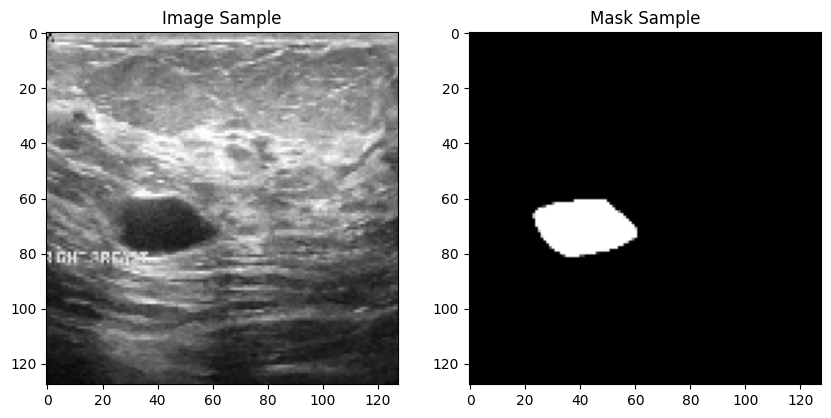

In [ ]:
# Visualize a sample to verify
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(images[0].reshape(size, size), cmap='gray')
plt.title("Image Sample")
plt.subplot(1, 2, 2)
plt.imshow(masks[0].reshape(size, size), cmap='gray')
plt.title("Mask Sample")
plt.show()

### 2.2 U-net architecture
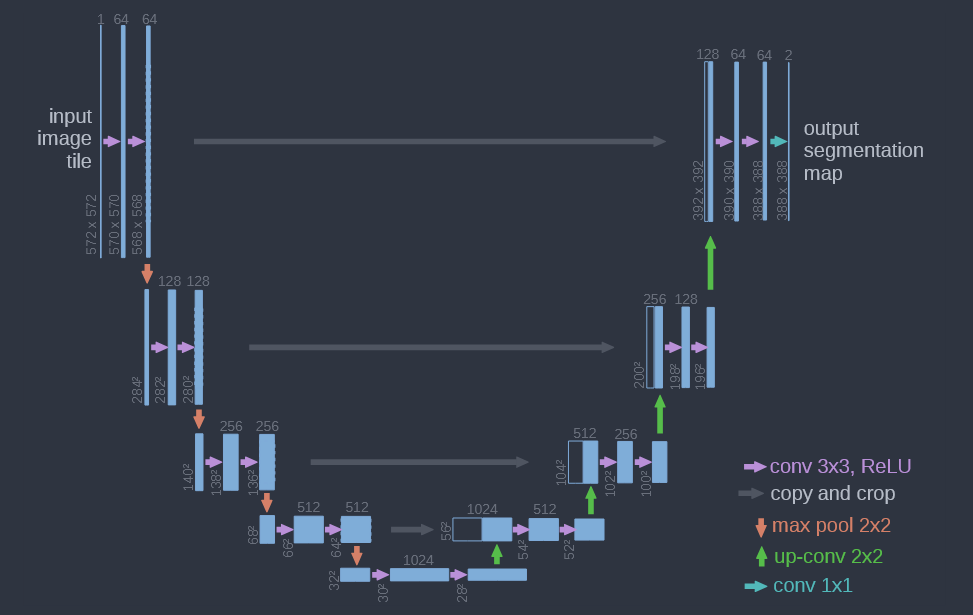


Splitting the data into **train**, **test**, and **validation** set

**Note:** `X = images` and `y = mask`

In [ ]:
X_train, X_tv, y_train, y_tv = train_test_split(images, masks, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_tv, y_tv, test_size=0.5, random_state=42)

#### 2.2.1 `Encoder`

In [ ]:
# First encoder block
input_layer = Input(shape=(size, size, 1))
conv1 = Conv2D(64, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(input_layer)
conv1 = Conv2D(64, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(conv1)
pool1 = MaxPooling2D(pool_size=(2,2))(conv1)

# Second encoder block
conv2 = Conv2D(128, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(pool1)
conv2 = Conv2D(128, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(conv2)
pool2 = MaxPooling2D(pool_size=(2,2))(conv2)

# Third encoder block
conv3 = Conv2D(256, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(pool2)
conv3 = Conv2D(256, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(conv3)
pool3 = MaxPooling2D(pool_size=(2,2))(conv3)

# Fourth encoder block
conv4 = Conv2D(512, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(pool3)
conv4 = Conv2D(512, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(conv4)
pool4 = MaxPooling2D(pool_size=(2,2))(conv4)

# Bottleneck
bottleneck = Conv2D(1024, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(pool4)
bottleneck = Conv2D(1024, (3,3), activation="relu", padding="same", kernel_initializer="he_normal")(bottleneck)

#### **He Normal Initialization**

To improve convergence, we use the **He Normal** (also known as **Kaiming Normal**) initializer. This method draws samples from a truncated normal distribution centered on 0 with a standard deviation adapted to the number of input units in the weight tensor.

The weights are initialized such that the variance is:

$$\text{Var}(W) = \frac{2}{n_{in}}$$

Where $n_{in}$ is the number of input units in the weight tensor (fan-in), calculated as:

$$n_{in} = \text{filter width} \times \text{filter height} \times \text{input channels (from prev. layer)}$$


This is particularly effective for deep networks using **ReLU** activation functions, as it helps maintain a stable variance of activations throughout the network layers.

#### 2.2.2 `Decoder`

In [ ]:
# First decoder block
upconv1 = Conv2DTranspose(512, (2,2), strides=(2,2), padding="same")(bottleneck)
upconv1 = concatenate([upconv1, conv4])
conv5 = Conv2D(512, (3,3), activation="relu", padding="same")(upconv1)
conv5 = Conv2D(512, (3,3), activation="relu", padding="same")(conv5)

# Second decoder block
upconv2 = Conv2DTranspose(256, (2,2), strides=(2,2), padding="same")(conv5)
upconv2 = concatenate([upconv2, conv3])
conv6 = Conv2D(256, (3,3), activation="relu", padding="same")(upconv2)
conv6 = Conv2D(256, (3,3), activation="relu", padding="same")(conv6)

# Third decoder block
upconv3 = Conv2DTranspose(128, (2,2), strides=(2,2), padding="same")(conv6)
upconv3 = concatenate([upconv3, conv2])
conv7 = Conv2D(128, (3,3), activation="relu", padding="same")(upconv3)
conv7 = Conv2D(128, (3,3), activation="relu", padding="same")(conv7)

# Fourth decoder block
upconv4 = Conv2DTranspose(64, (2,2), strides=(2,2), padding="same")(conv7)
upconv4 = concatenate([upconv4, conv1])
conv8 = Conv2D(64, (3,3), activation="relu", padding="same")(upconv4)
conv8 = Conv2D(64, (3,3), activation="relu", padding="same")(conv8)

### 2.3 Ouput layer + Model creation

In [ ]:
output_layer = Conv2D(1, (1,1), activation="sigmoid", padding="same")(conv8)

model = Model(inputs = input_layer, outputs = output_layer)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import mixed_precision

# Enable mixed precision for faster training on T4 GPU
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Re-compile to apply the policy if needed, then fit with a larger batch size
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.fit(X_train, y_train,
          epochs=100,
          batch_size=32,
          validation_data=(X_val, y_val),
          verbose=1)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.8817 - loss: 0.3872 - val_accuracy: 0.9163 - val_loss: 0.3160
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 428ms/step - accuracy: 0.8541 - loss: 0.7081 - val_accuracy: 0.9163 - val_loss: 0.3507
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 438ms/step - accuracy: 0.9036 - loss: 0.3408 - val_accuracy: 0.9163 - val_loss: 0.3069
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 459ms/step - accuracy: 0.8954 - loss: 0.3169 - val_accuracy: 0.9163 - val_loss: 0.3093
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 475ms/step - accuracy: 0.9036 - loss: 0.2809 - val_accuracy: 0.9165 - val_loss: 0.3066
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 479ms/step - accuracy: 0.9038 - loss: 0.2540 - val_accuracy: 0.9225 - val_loss: 0.2224
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - accuracy: 0.9089 - loss: 0.2308 - val_accuracy: 0.9275 - val_loss: 0.1991
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 443ms/step - accuracy: 0.9217 - loss: 0.2085 - val_accu

## **3. Model evaluation**

### 3.1 Intersection over Union (`IoU`) score

In [ ]:
from sklearn.metrics import jaccard_score

# Generate predictions for the test set
y_pred = model.predict(X_test, verbose=1)

# Binarize predictions and ground truth (using 0.5 threshold)
y_pred_thresholded = (y_pred > 0.5).astype(np.uint8)
y_test_binarized = (y_test > 0.5).astype(np.uint8)

# Calculate Jaccard Score (IoU)
# Flattening is necessary to compute the score across all pixels in the test set
iou_score = jaccard_score(y_test_binarized.flatten(), y_pred_thresholded.flatten())

print(f"Jaccard Score (IoU) on Test Set: {iou_score:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 658ms/step
Jaccard Score (IoU) on Test Set: 0.6673


**`IoU` Formulas**

For binary segmentation, we define the following metrics:

**1. IoU for Background (Class 0):**

$$IoU_0 = \frac{TP_0}{TP_0 + FP_0 + FN_0}$$

**2. IoU for Foreground (Class 1):**

$$IoU_1 = \frac{TP_1}{TP_1 + FP_1 + FN_1}$$

**3. Mean IoU (mIoU):**

$$mIoU = \frac{IoU_0 + IoU_1}{2}$$

In [ ]:
from keras.metrics import MeanIoU

# Keras MeanIoU requires integer labels (0, 1)
# We use the thresholded predictions we already calculated
mean_iou_metric = MeanIoU(num_classes=2)
mean_iou_metric.update_state(y_test_binarized, y_pred_thresholded)

print(f"Mean IoU (Average of Class 0 and 1): {mean_iou_metric.result().numpy():.4f}")

Mean IoU (Average of Class 0 and 1): 0.8154


## **4. Visuallizing: Predicted vs Ground truth**

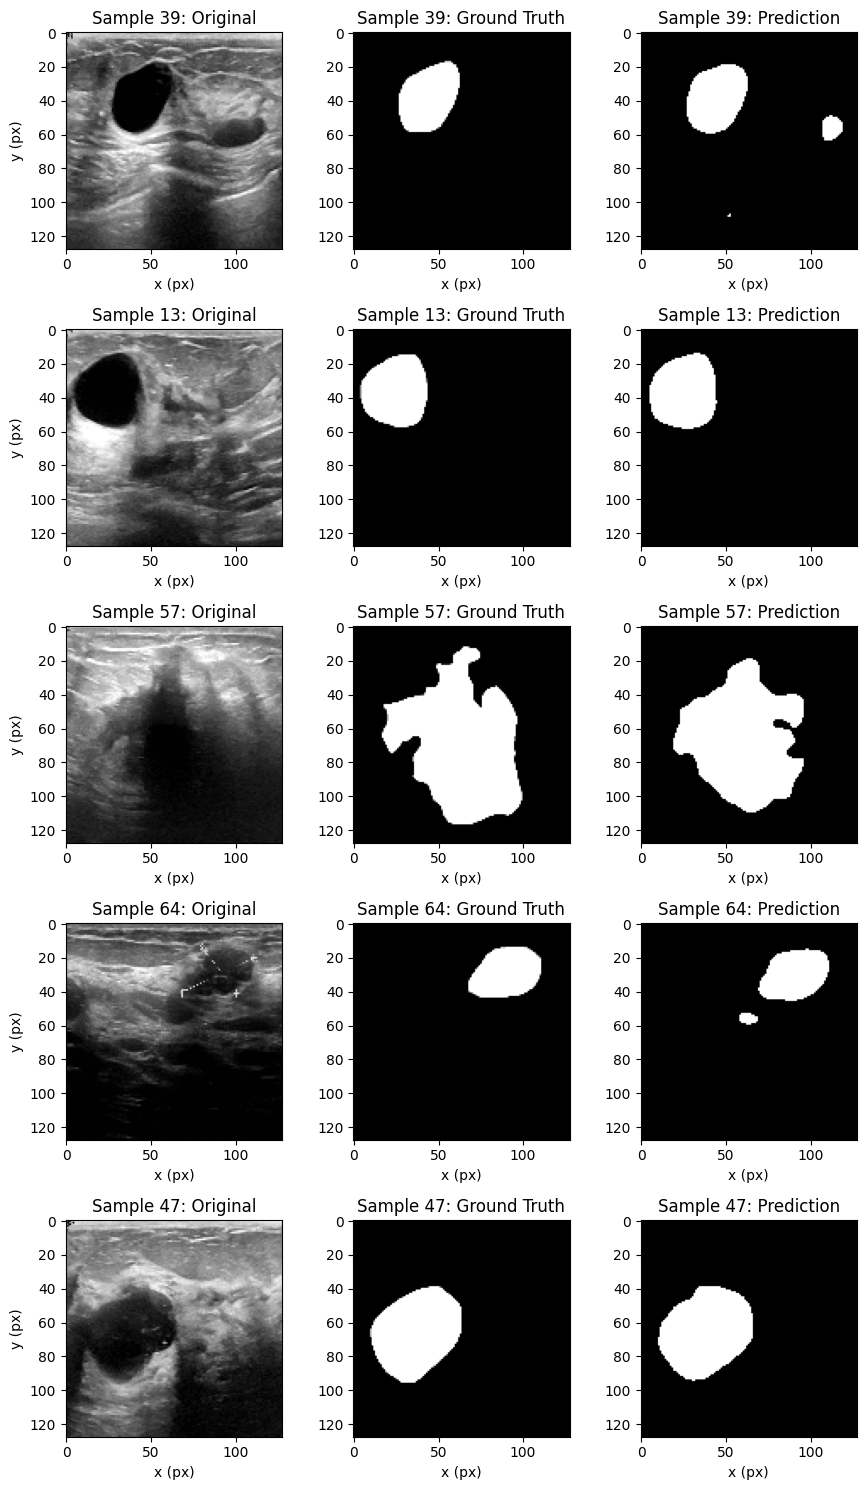

In [ ]:
import random

# We will plot 5 rows (3 different samples), each with 3 columns
num_samples = 5
# Reduced figsize for better fit
fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))

for i in range(num_samples):
    # Select a random index
    idx = random.randint(0, len(X_test) - 1)

    # Original Image
    axes[i, 0].imshow(X_test[idx].reshape(size, size), cmap="gray")
    axes[i, 0].set_title(f"Sample {idx}: Original")
    axes[i, 0].grid(False)
    axes[i, 0].set_aspect('equal')
    axes[i, 0].set_xlabel("x (px)")
    axes[i, 0].set_ylabel("y (px)")

    # Ground Truth Mask
    axes[i, 1].imshow(y_test[idx].reshape(size, size), cmap="gray")
    axes[i, 1].set_title(f"Sample {idx}: Ground Truth")
    axes[i, 1].grid(False)
    axes[i, 1].set_aspect('equal')
    axes[i, 1].set_xlabel("x (px)")

    # Predicted Mask
    axes[i, 2].imshow(y_pred_thresholded[idx].reshape(size, size), cmap="gray")
    axes[i, 2].set_title(f"Sample {idx}: Prediction")
    axes[i, 2].grid(False)
    axes[i, 2].set_aspect('equal')
    axes[i, 2].set_xlabel("x (px)")

plt.tight_layout()
plt.show()